# 🍷 Wine Classifier — rozpoznawanie winiarni po składzie chemicznym

Projekt z uczenia maszynowego — klasyfikacja wieloklasowa + porównanie modeli.

## 👤 Skład zespołu

| Imię i nazwisko | Rola |
|---|---|
| Maksymilian Kaczmarek | Autor projektu (projekt indywidualny) |

##**Koncepcja projektu**

### Cel
Klasyfikacja wielowymiarowa: na podstawie **13 cech chemicznych** wina przewidujemy, z której z **trzech winiarni** (cultivar) pochodzi próbka.

### Dwie części projektu
**Część 1 — Wine (realne dane):** 4 modele klasyfikujące + analiza porównawcza + różne konfiguracje.

**Część 2 — Two Moons (eksperyment):** syntetyczny zbiór nieliniowy, na którym pokażemy **kiedy** wybór modelu ma znaczenie — z wizualizacją granic decyzyjnych. To odpowiedź na pytanie: dlaczego na Wine modele wychodzą podobnie, a na innym problemie mogą się drastycznie różnić?

### Pytania badawcze
- Czy sam skład chemiczny wystarcza do rozpoznania winiarni?
- Które cechy chemiczne najmocniej różnicują winiarnie?
- Kiedy złożone modele (drzewa, sieci) biją proste (liniowe), a kiedy nie?

### Dane
🔗 [UCI Wine Dataset — Kaggle](https://www.kaggle.com/datasets/aarontanjaya/uci-wine-dataset)

178 próbek win z jednego regionu Włoch, 3 różne odmiany (cultivars), 13 cech chemicznych.

## 🔧 Środowisko i biblioteki

In [1]:
!pip install xgboost plotly -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import make_moons

# Modele klasyfikujące
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Metryki
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print("Biblioteki zaimportowane")

Biblioteki zaimportowane


## 📥 Pobranie danych z Kaggle

In [3]:
import kagglehub
path = kagglehub.dataset_download("aarontanjaya/uci-wine-dataset")
print("Path:", path)

100%|██████████| 4.18k/4.18k [00:00<00:00, 6.09MB/s]

Extracting files...
Path: /root/.cache/kagglehub/datasets/aarontanjaya/uci-wine-dataset/versions/3


In [4]:
import os
print(os.listdir(path))

['wine.data']


In [5]:
column_names = ['target', 'alcohol', 'malic_acid', 'ash', 'ash_alcalinity',
                'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
                'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline']

df = pd.read_csv(path + '/wine.data', header=None, names=column_names)
print("Wymiary:", df.shape)
df.head()

Wymiary: (178, 14)


,target,alcohol,malic_acid,ash,ash_alcalinity,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 📊 Opis danych

13 cech chemicznych + kolumna `target` (winiarnia 1/2/3):

| Cecha | Opis |
|---|---|
| `alcohol` | Zawartość alkoholu |
| `malic_acid` | Kwas jabłkowy |
| `ash` | Popiół |
| `ash_alcalinity` | Zasadowość popiołu |
| `magnesium` | Magnez |
| `total_phenols` | Fenole ogółem |
| `flavanoids` | Flawonoidy |
| `nonflavanoid_phenols` | Fenole nieflawonoidowe |
| `proanthocyanins` | Proantocyjaniny |
| `color_intensity` | Intensywność koloru |
| `hue` | Odcień |
| `od280_od315` | OD280/OD315 (miara rozcieńczenia) |
| `proline` | Prolina (aminokwas) |

## 🔍 Diagnostyka i czyszczenie

In [6]:
print("=== TYPY ===")
print(df.dtypes)
print("\n=== BRAKI ===")
print(df.isnull().sum())
print("\n=== ROZKŁAD KLAS ===")
print(df['target'].value_counts())

=== TYPY ===
target                    int64
alcohol                 float64
malic_acid              float64
ash                     float64
ash_alcalinity          float64
magnesium                 int64
total_phenols           float64
flavanoids              float64
nonflavanoid_phenols    float64
proanthocyanins         float64
color_intensity         float64
hue                     float64
od280_od315             float64
proline                   int64
dtype: object

=== BRAKI ===
target                  0
alcohol                 0
malic_acid              0
ash                     0
ash_alcalinity          0
magnesium               0
total_phenols           0
flavanoids              0
nonflavanoid_phenols    0
proanthocyanins         0
color_intensity         0
hue                     0
od280_od315             0
proline                 0
dtype: int64

=== ROZKŁAD KLAS ===
target
2    71
1    59
3    48
Name: count, dtype: int64


In [7]:
# Statystyki opisowe — sprawdzamy zakresy cech
df.describe()

,target,alcohol,malic_acid,ash,ash_alcalinity,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Dataset UCI Wine jest znany z tego, że jest kompletny i czysty — brak brakow, brak bledow. Brak konieczności usuwania rekordów to też wniosek (w przeciwieństwie do danych z prawdziwego świata). Cechy mają jednak rozne skale (np. `proline` w setkach, `hue` w okolicach 1) — to wymusza skalowanie przed modelami liniowymi i sieciami.

## 🔍 Eksploracyjna Analiza Danych (EDA)

In [8]:
# Rozkład klas
counts = df['target'].value_counts().sort_index().reset_index()
counts.columns = ['Winiarnia', 'Liczba']
fig = px.bar(counts, x='Winiarnia', y='Liczba',
             title='Liczba próbek na winiarnię', color='Winiarnia')
fig.show()

In [9]:
# Macierz korelacji cech
corr = df.drop(columns='target').corr()
fig = px.imshow(corr, text_auto='.2f', aspect='auto',
                color_continuous_scale='RdBu_r',
                title='Macierz korelacji cech chemicznych')
fig.update_layout(height=700)
fig.show()

macierz korelacji pokazuje ciekawe zależności które odzwierciedlają naturalne powiązania chemiczne między różnymi związkami.

np **hue - malic_acid = -0.56** ponieważ im więcej kwasu jabłkowego tym niższy odcień. albo

np. wysoka korelacja **total_phenols - flavanoids = 0.86** oznacza redundancję czyli to że te dwie cechy niosą podobną informację (w tym przypadku duża ilośc jednego nie wyklucza, a nawet wskazuje, na dużą ilość drugiego składnika w winie)

In [10]:
# Przykładowy rozkład: alkohol wg winiarni (boxplot)
fig = px.box(df, x='target', y='alcohol', color='target',
             title='Zawartość alkoholu wg winiarni',
             labels={'target': 'Winiarnia', 'alcohol': 'Alkohol'})
fig.show()

## 🎯 Wizualizacja PCA — redukcja 13 wymiarów do 2

PCA (Principal Component Analysis) sprowadza 13 cech do 2 głównych składowych, pozwalając **zobaczyć** jak winiarnie układają się w przestrzeni. Jeśli klasy są wyraźnie odseparowane — klasyfikacja będzie łatwa.

In [11]:
X_all = df.drop(columns='target')
y_all = df['target']

# Skalujemy przed PCA
X_scaled_all = StandardScaler().fit_transform(X_all)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_all)

pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1],
                       'Winiarnia': y_all.astype(str)})

fig = px.scatter(pca_df, x='PC1', y='PC2', color='Winiarnia',
                 title='PCA — winiarnie w 2D (z 13 cech)',
                 opacity=0.8)
fig.show()

print(f"Wyjaśniona wariancja: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}")

Wyjaśniona wariancja: PC1=36.2%, PC2=19.2%


# 🤖 CZĘŚĆ 1 — Klasyfikacja winiarni (4 modele)

In [24]:
X = df.drop(columns='target')
y = df['target']

# Skalowanie (LogReg i MLP tego wymagają)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Podział ze stratyfikacją (zachowuje proporcje klas)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 133 | Test: 45


In [25]:
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0),
    'MLP': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
}

results = []
for name, model in classifiers.items():
    if name == 'XGBoost':
        model.fit(X_train, y_train_xgb)
        y_pred = model.predict(X_test) + 1
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({'Model': name, 'Accuracy': round(acc, 4), 'F1': round(f1, 4)})

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(results_df)

                 Model  Accuracy      F1
1        Random Forest    1.0000  1.0000
2              XGBoost    1.0000  1.0000
0  Logistic Regression    0.9778  0.9776
3                  MLP    0.9556  0.9554


In [14]:
# Wykres porównania modeli
fig = px.bar(results_df, x='Model', y='Accuracy',
             title='Porównanie klasyfikatorów — trafność',
             color='Accuracy', color_continuous_scale='Purples',
             text='Accuracy', range_y=[0.8, 1.02])
fig.update_traces(textposition='outside')
fig.show()

## 🔁 Walidacja krzyżowa (cross-validation)

Pojedynczy podział train/test może być 'szczęśliwy'. Walidacja krzyżowa (5-fold) trenuje model 5 razy na różnych podziałach i uśrednia wynik — daje rzetelniejszą ocenę.

In [15]:
print("5-fold cross-validation (accuracy):\n")
for name, model in classifiers.items():
    if name == 'XGBoost':
        scores = cross_val_score(model, X_scaled, y - 1, cv=5)
    else:
        scores = cross_val_score(model, X_scaled, y, cv=5)
    print(f"{name:22s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

5-fold cross-validation (accuracy):

Logistic Regression   : 0.9889 (+/- 0.0136)
Random Forest         : 0.9721 (+/- 0.0176)
XGBoost               : 0.9498 (+/- 0.0407)
MLP                   : 0.9722 (+/- 0.0304)


mega ważne jest zastosowanie również tej próby cross validation aby wyłapać "szczęśliwy podział". RF w pojedynczym teście uzyskało 100% skutecznosci ale juz w cross validation 5times uzyskalo mniej. Wręcz tabela się odwócila i LR jest najskuteczniejszy i najstabilniejszy. LR jest bardzo prostym modelem stąd ta stabilność. Pozostałe modele "przekombinowują" na małym zboirze danych stąd większe odchylenia.

## 📊 Confusion Matrix — najlepszy model

In [16]:
# Confusion matrix dla Random Forest
rf = classifiers['Random Forest']
y_pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

fig = px.imshow(cm, text_auto=True, aspect='auto',
                x=['Winiarnia 1', 'Winiarnia 2', 'Winiarnia 3'],
                y=['Winiarnia 1', 'Winiarnia 2', 'Winiarnia 3'],
                color_continuous_scale='Purples',
                labels={'x': 'Predykcja', 'y': 'Rzeczywista'},
                title='Confusion Matrix — Random Forest')
fig.show()

tutaj mamy idealny wynik 100% z pojedynczego testu RF, wszystkie 45 win testowych jest poprawnie dopasowanych. gdyby np w komorce winiarnia 2 winiarnia 1 byłaby jedna pozycja oznaczałoby to złą predykcje i niestuprocentową skuteczność

## 📊 Feature Importance — co różnicuje winiarnie

In [17]:
imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig = px.bar(imp, x='importance', y='feature', orientation='h',
             title='Ważność cech — Random Forest',
             color='importance', color_continuous_scale='Purples')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

 tutaj 5-6 cech wspólnie decyduje o klasyfikacji, każda wnosząc 10-17%. To znaczy że winiarnie różnią się wieloma parametrami chemicznymi naraz, nie jednym.

 jeszcze ciekawa obserwacja, że color_intensity i flavanoids miało silne korelacje w macierzy a tutaj jest w czołówce importance.

## ⚙️ Różne konfiguracje modelu — wpływ liczby drzew (Random Forest)

Sprawdzamy jak liczba drzew (`n_estimators`) wpływa na trafność — to 'analiza różnych konfiguracji' wymagana na wyższą ocenę.

In [18]:
n_trees = [1, 5, 10, 25, 50, 100, 200]
accs = []
for n in n_trees:
    m = RandomForestClassifier(n_estimators=n, random_state=42)
    m.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, m.predict(X_test)))

fig = px.line(x=n_trees, y=accs, markers=True,
              title='Wpływ liczby drzew na trafność (Random Forest)',
              labels={'x': 'Liczba drzew (n_estimators)', 'y': 'Trafność'})
fig.show()

- 1 drzewo → ~86.7% (słabo, to po prostu jedno drzewo decyzyjne)

- 5 drzew → ~93% (szybki skok)

- 10-25 drzew → ~97%.
- 50+ drzew → 100%, i dalej płasko



Więcej drzew = lepiej, ale do pewnego momentu. Po ~50 drzewach dodawanie kolejnych nic nie daje — model już osiągnął maksimum. 100 czy 200 drzew daje identyczny wynik jak 50.

# 🌙 CZĘŚĆ 2 — Two Moons: kiedy wybór modelu ma znaczenie

Na Wine wszystkie modele wypadły podobnie, bo problem jest **liniowo separowalny**. Aby pokazać, **kiedy** wybór modelu jest kluczowy, generujemy syntetyczny zbiór **two moons** — dwa przeplecione półksiężyce, których prosta linia nie rozdzieli.

# Po co w ogóle dodawać sztuczny zbiór?
kontrast do łatwego problemu

In [19]:
# Generujemy two moons
X_moons, y_moons = make_moons(n_samples=1000, noise=0.2, random_state=42)

moons_df = pd.DataFrame({'x': X_moons[:, 0], 'y': X_moons[:, 1],
                         'klasa': y_moons.astype(str)})
fig = px.scatter(moons_df, x='x', y='y', color='klasa',
                 title='Two Moons — zbiór nieliniowy', opacity=0.6)
fig.show()

tu zaobserwujemy zjawisko gdzie LR nie będzie mogło narysować prostej linii oddzielającej dwa zbiory, dlatego sobie nie poradzi. RF XGB i MLP dadzą radę bo uczą się "zakrętów".

In [20]:
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    X_moons, y_moons, test_size=0.25, random_state=42)

moons_models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0),
    'MLP': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=42)
}

moons_results = []
for name, model in moons_models.items():
    model.fit(Xm_tr, ym_tr)
    acc = accuracy_score(ym_te, model.predict(Xm_te))
    moons_results.append({'Model': name, 'Accuracy': round(acc, 4)})

moons_df_res = pd.DataFrame(moons_results).sort_values('Accuracy', ascending=False)
print(moons_df_res)

                 Model  Accuracy
3                  MLP     0.980
1        Random Forest     0.976
2              XGBoost     0.976
0  Logistic Regression     0.880


widać że LR ma słabą skuteczność.

tu chodzi o pokazanie tego że nie ma najlepszego modelu, wszystko zależy od natury danych. Na łatwym problemie prosty model wygrywa, na trudnym przegrywa.

MLP poradził sobie tutaj dobrze ponieważ dostał dużo próbek. więcej danych dla sieci neuronowej i jest oczywiscie nieliniowy a MLP to lubi najbardziej.

## 🎨 Wizualizacja granic decyzyjnych

Najlepsza część — **widzimy** jak każdy model dzieli przestrzeń. Linear Regression rysuje prostą linię (i przegrywa), drzewa/sieci uczą się zakrętów.

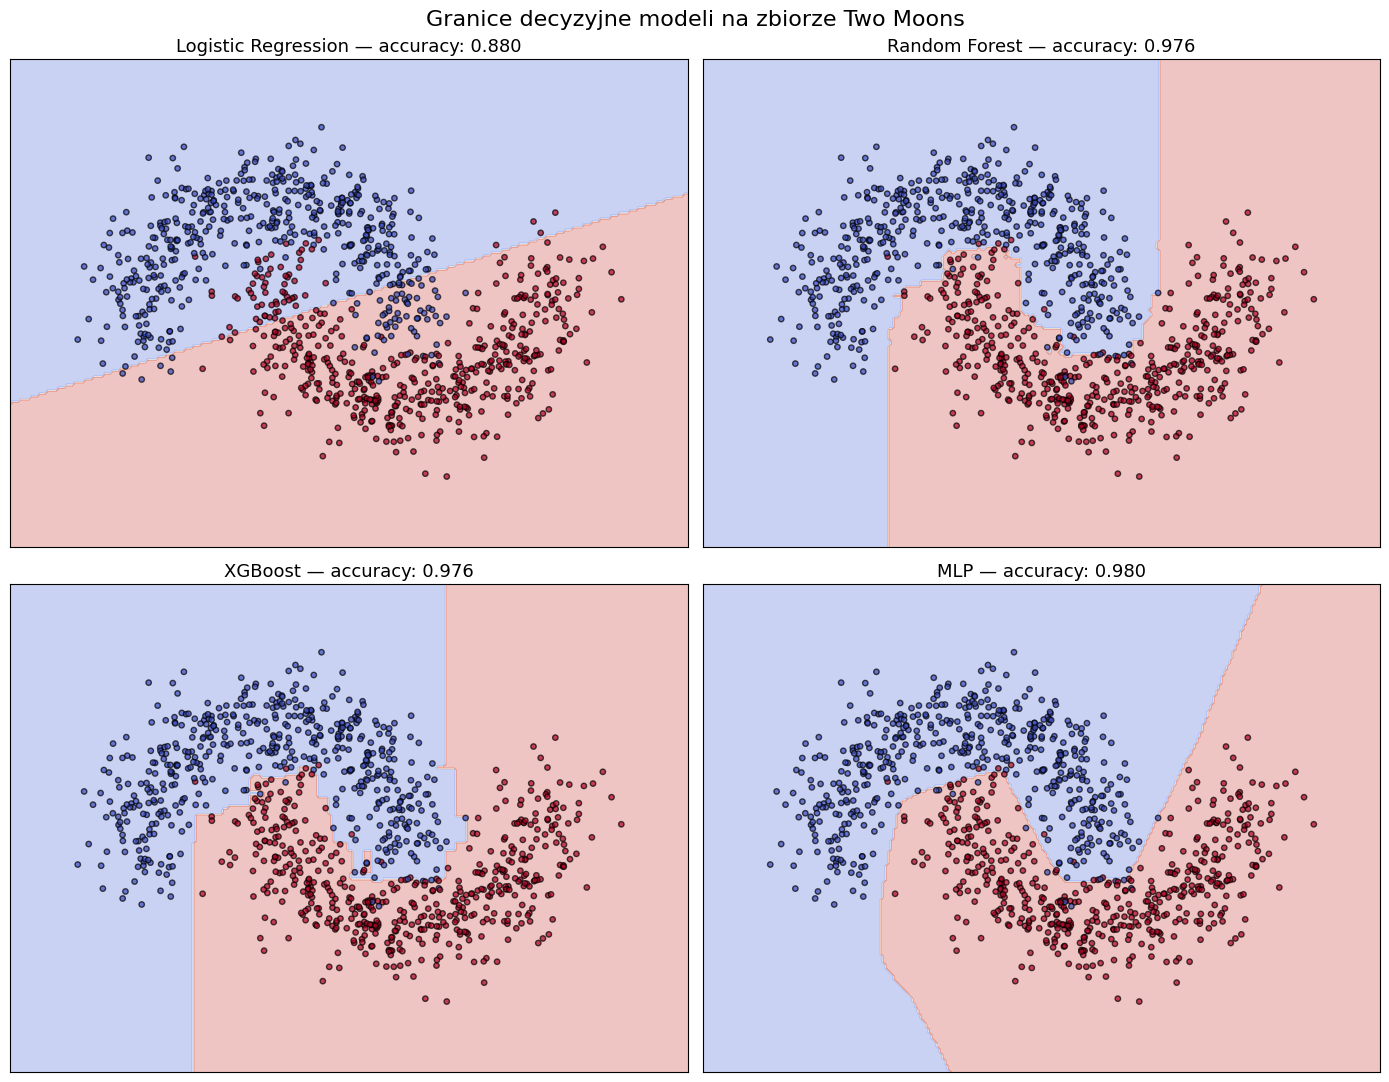

In [21]:
# Siatka punktów do narysowania granic decyzyjnychř
h = 0.02
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

for idx, (name, model) in enumerate(moons_models.items()):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax = axes[idx]
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons,
               cmap='coolwarm', edgecolors='k', s=15, alpha=0.7)
    acc = accuracy_score(ym_te, model.predict(Xm_te))
    ax.set_title(f'{name} — accuracy: {acc:.3f}', fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Granice decyzyjne modeli na zbiorze Two Moons', fontsize=16)
plt.tight_layout()
plt.show()

In [26]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Siatka punktów (rzadsza niż w matplotlib, bo Plotly cięższy)
h = 0.05
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig = make_subplots(rows=2, cols=2,
                    subplot_titles=[f"{name} ({accuracy_score(ym_te, m.predict(Xm_te)):.1%})"
                                    for name, m in moons_models.items()])

positions = [(1, 1), (1, 2), (2, 1), (2, 2)]

for (name, model), (r, c) in zip(moons_models.items(), positions):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    # Tło — granica decyzyjna
    fig.add_trace(go.Heatmap(x=xx[0], y=yy[:, 0], z=Z,
                             colorscale='RdBu', showscale=False, opacity=0.3),
                  row=r, col=c)
    # Punkty danych
    fig.add_trace(go.Scatter(x=X_moons[:, 0], y=X_moons[:, 1],
                             mode='markers',
                             marker=dict(color=y_moons, colorscale='RdBu',
                                         size=4, line=dict(width=0.5, color='black')),
                             showlegend=False),
                  row=r, col=c)

fig.update_layout(height=700, title_text='Interaktywne granice decyzyjne — Two Moons')
fig.show()

## 🏁 Wnioski końcowe

### Część 1 — Wine
- Wszystkie 4 modele osiągają wysoką trafność (95–99% w walidacji krzyżowej), bo problem jest **liniowo separowalny** — widać to na PCA, gdzie trzy winiarnie tworzą wyraźnie odseparowane grupy już w 2 wymiarach.
- Najważniejsze cechy różnicujące winiarnie to **color_intensity, flavanoids, alcohol, proline i hue** — wpływ jest rozłożony na kilka cech, nie zdominowany przez jedną.
- **Kluczowa obserwacja:** w walidacji krzyżowej najlepszy okazał się **Logistic Regression (98.9%)** — najprostszy model. XGBoost wypadł najsłabiej (95.0%) i najmniej stabilnie (±4.1%). Pojedynczy podział sugerował 100% dla Random Forest i XGBoost, ale cross-validation ujawniło, że to był "szczęśliwy podział".
- Skoro nawet prosty model liniowy trafia niemal idealnie, złożone modele nie mają czego poprawiać — a wręcz tracą stabilność (brzytwa Ockhama).

### Część 2 — Two Moons
- **Logistic Regression drastycznie przegrywa (88.0%)**, bo prosta linia nie jest w stanie rozdzielić dwóch przeplecionych półksiężyców.
- **MLP (98.0%), Random Forest (97.6%) i XGBoost (97.6%)** radzą sobie świetnie, bo uczą się nieliniowych granic decyzyjnych.
- Wizualizacja granic decyzyjnych pokazuje **dlaczego** — Logistic Regression rysuje jedną prostą linię (część każdego półksiężyca zawsze ląduje po złej stronie), podczas gdy pozostałe modele "owijają się" wokół kształtu danych.

### Porównanie obu części — ten sam model, skrajnie różne wyniki
| Model | Wine (CV) | Two Moons |
|---|---|---|
| Logistic Regression | **98.9%** (najlepszy) | **88.0%** (najgorszy) |
| MLP | 97.2% | 98.0% |
| Random Forest | 97.2% | 97.6% |
| XGBoost | 95.0% | 97.6% |

Logistic Regression był **najlepszy** na Wine i **najgorszy** na Two Moons — ta sama metoda, odwrotny wynik.

### Główny wniosek
**Wybór modelu ma znaczenie tylko wtedy, gdy problem jest złożony (nieliniowy).** Na łatwych, liniowo separowalnych danych (Wine) prosty model wystarcza, a nawet wygrywa stabilnością. Na trudnych, nieliniowych danych (Two Moons) różnica między modelami jest dramatyczna (10 punktów procentowych). Dobór modelu powinien wynikać z **natury danych**, a nie z założenia, że istnieje uniwersalnie "najlepszy" algorytm.

### Ograniczenia
- Wine to mały zbiór (178 próbek) — pojedyncze podziały train/test są niestabilne, dlatego oparliśmy ocenę na walidacji krzyżowej.
- Two Moons to dane **syntetyczne** — służą do demonstracji zachowania modeli, nie reprezentują rzeczywistego zjawiska.
- Wnioski o trafności dotyczą tych konkretnych zbiorów; na innych danych ranking modeli może wyglądać inaczej (co zresztą jest głównym przesłaniem projektu).